# Στατιστικός Έλεγχος Διεργασίας του Πάχους Επικάλυψης σε Γραμμές Παραγωγής με το PROC BOXPLOT

## Συνοπτική Παρουσίαση

Αυτό το σημειωματάριο χρησιμοποιεί το **PROC BOXPLOT** για να εκτελέσει στατιστικό έλεγχο διεργασίας (SPC) σε μια κρίσιμη για την ποιότητα μέτρηση του πάχους επικάλυψης, η οποία συλλέγεται από τέσσερις παράλληλες γραμμές παραγωγής. Δημιουργούμε συνθετικά δεδομένα μετρήσεων ενσωματωμένα, χαρακτηρίζουμε τις γραμμές με το `PROC MEANS` και σχεδιάζουμε σκελετικά και σχηματικά διαγράμματα πλαισίου-μουστακιού (box-and-whisker) που συγκρίνουν τη θέση, τη διασπορά και τις ουρές μεταξύ των γραμμών σε ένα ενιαίο διάγραμμα.

Στη συνέχεια αξιολογούμε κάθε γραμμή ως προς την τεχνική προδιαγραφή (στόχος 50.00 mm, όρια 49.80–50.20 mm) απευθείας από το σύνολο στατιστικών **`OUTBOX=`** — τα ακριβή τεταρτημόρια, τους φράχτες και τα άκρα των μουστακιών πίσω από κάθε πλαίσιο — και τέλος επιδεικνύουμε τη διαδρομή μετ' επιστροφής **`OUTHISTORY=` / `HISTORY=`**: το PROC BOXPLOT εξάγει μία συμπαγή γραμμή περίληψης ανά γραμμή παραγωγής, και ένα δεύτερο PROC BOXPLOT ανακατασκευάζει ένα πανομοιότυπο διάγραμμα κατευθείαν από αυτήν την περίληψη, το μοτίβο που χρησιμοποιεί ένας καθημερινός πίνακας ελέγχου SPC για να επανασχεδιάσει χωρίς να επανασαρώσει τις ακατέργαστες μετρήσεις.

Στις τέσσερις γραμμές, η **LINE-A είναι η καλύτερα κεντραρισμένη** στον στόχο (μέση τιμή 50.008 mm), η **LINE-C τρέχει χαμηλά** (μέση τιμή 49.932 mm, μετατοπιζόμενη προς το LSL) και η **LINE-D τρέχει τόσο ψηλά όσο και με τη μεγαλύτερη μεταβλητότητα** (μέση τιμή 50.102 mm, τυπική απόκλιση 0.080 mm) — το μέγιστό της, 50.248 mm, είναι η μοναδική παρατήρηση που παραβιάζει το άνω όριο προδιαγραφής των 50.20 mm.

## Πηγές Δεδομένων

Όλα τα δεδομένα είναι συνθετικά και δημιουργούνται ενσωματωμένα από το πρώτο βήμα DATA χρησιμοποιώντας `call streaminit(20250531)` και `rand()`. Δεν χρησιμοποιείται καμία εξωτερική ή δικτυακή είσοδος. Ο σταθερός σπόρος (seed) καθιστά κάθε αριθμό σε αυτό το σημειωματάριο αναπαραγώγιμο.

**Σύνολο δεδομένων: `ProcessMeas`** (μία γραμμή ανά μετρημένο εξάρτημα)

| Μεταβλητή | Τύπος | Περιγραφή |
|----------|------|-------------|
| `Line` | Char(6) | Αναγνωριστικό γραμμής παραγωγής: `LINE-A`, `LINE-B`, `LINE-C`, `LINE-D` (η μεταβλητή ομάδας/ταξινόμησης) |
| `Shift` | Num | Δείκτης βάρδιας παραγωγής 1–6 (εισάγει ήπια μετατόπιση μεταξύ βαρδιών) |
| `Thickness` | Num | Πάχος επικάλυψης σε mm (η μεταβλητή ανάλυσης)· στόχος 50.00 mm, όρια προδιαγραφής 49.80–50.20 mm |

Κάθε γραμμή είναι κεντραρισμένη σε ελαφρώς διαφορετική μέση τιμή (50.00 / 50.04 / 49.92 / 50.10) με μεταβλητότητα ειδική ανά γραμμή, μιμούμενη πραγματικές διαφορές από εξοπλισμό σε εξοπλισμό, και η `LINE-B` εισάγει περιστασιακά μια μικρή θετική απόκλιση. Το βήμα DATA επαναλαμβάνεται σε έξι βάρδιες και τέσσερις γραμμές με μεγέθη υποομάδων περίπου 18–25 εξαρτημάτων το καθένα· σε αυτό το περιβάλλον χωρίς άδεια χρήσης, η μηχανή περιορίζει την έξοδο στις πρώτες **100 παρατηρήσεις**, οι οποίες εδώ κατανέμονται ως **38 / 19 / 21 / 22** εξαρτήματα για τις LINE-A έως LINE-D — και πάλι επαρκείς για να γεμίσουν τέσσερα σαφώς καθορισμένα πλαίσια.

# Στατιστικός Έλεγχος Διεργασίας του Πάχους Επικάλυψης με το PROC BOXPLOT

Στη μεταποίηση μεγάλου όγκου, ένα διάγραμμα πλαισίου-μουστακιού είναι το εργαλείο αναφοράς του SPC στο εργοστάσιο: συνοψίζει την κεντρική τάση, τη διασπορά και τις ακραίες τιμές ενός χαρακτηριστικού ποιότητας για κάθε μονάδα παραγωγής σε ένα ενιαίο διάγραμμα. Εδώ παρακολουθούμε το **πάχος επικάλυψης (mm)** σε ένα εξάρτημα που παράγεται παράλληλα σε τέσσερις γραμμές (`LINE-A` έως `LINE-D`). Η τεχνική προδιαγραφή είναι ένας στόχος **50.00 mm** με κάτω όριο προδιαγραφής (LSL) **49.80 mm** και άνω όριο προδιαγραφής (USL) **50.20 mm**.

Θα:

1. Δημιουργήσουμε ένα συνθετικό σύνολο δεδομένων μετρήσεων ενσωματωμένα.
2. Χαρακτηρίσουμε τις γραμμές με το `PROC MEANS`.
3. Σχεδιάσουμε ένα βασικό σκελετικό διάγραμμα πλαισίου, έπειτα ένα σχηματικό διάγραμμα, επικαλύπτοντας τα όρια προδιαγραφής ως γραμμές αναφοράς.
4. Καταγράψουμε κάθε υπολογισμένο στατιστικό στοιχείο πλαισίου με το `OUTBOX=` και αξιολογήσουμε κάθε γραμμή ως προς τα όρια προδιαγραφής από αυτόν τον πίνακα.
5. Διατηρήσουμε μια συμπαγή περίληψη υποομάδας με το `OUTHISTORY=` και αποδείξουμε τη διαδρομή μετ' επιστροφής επανασχεδιάζοντας κατευθείαν από αυτήν με το `HISTORY=`.

## Βήμα 1 — Δημιουργία συνθετικών μετρήσεων διεργασίας

Το παρακάτω βήμα DATA προσομοιώνει μετρήσεις σε έξι βάρδιες σε τέσσερις γραμμές. Κάθε γραμμή είναι σκόπιμα κεντραρισμένη σε ελαφρώς διαφορετική μέση τιμή με τη δική της μεταβλητότητα, μιμούμενη πραγματικές διαφορές από εξοπλισμό σε εξοπλισμό, και μια ήπια μετατόπιση μεταξύ βαρδιών προστίθεται με έναν όρο `sin(Shift)`. Ένας σταθερός σπόρος (`streaminit(20250531)`) καθιστά κάθε τιμή στο σημειωματάριο αναπαραγώγιμη.

In [1]:
ΔΕΔΟΜΕΝΑ ProcessMeas;
   CALL streaminit(20250531);
   LENGTH Line $6;
   ARRAY lines[4] $6 _temporary_ ('LINE-A' 'LINE-B' 'LINE-C' 'LINE-D');
   ARRAY lmean[4]   _temporary_ (50.00 50.04 49.92 50.10);
   ARRAY LSD[4]     _temporary_ (0.045 0.060 0.050 0.085);
   ΕΤΙΚΕΤΑ Thickness='Πάχος επικάλυψης (mm)' Line='Γραμμή παραγωγής';
   ΕΠΑΝΑΛΗΨΗ Shift = 1 ΕΩΣ 6;
      ΕΠΑΝΑΛΗΨΗ li = 1 ΕΩΣ 4;
         Line = lines[li];
         /* varying subgroup size per line/shift */
         n = 18 + floor(rand('uniform') * 8);
         ΕΠΑΝΑΛΗΨΗ u = 1 ΕΩΣ n;
            BASE = lmean[li] + 0.012 * sin(Shift);
            Thickness = BASE + rand('normal') * LSD[li];
            /* LINE-B injects occasional high excursions */
            ΕΑΝ li = 2 AND rand('uniform') < 0.05 ΤΟΤΕ
               Thickness = Thickness + rand('uniform') * 0.40;
            Thickness = round(Thickness, 0.001);
            ΕΞΟΔΟΣ;
         ΤΕΛΟΣ;
      ΤΕΛΟΣ;
   ΤΕΛΟΣ;
   ΑΦΑΙΡΕΣΗ li u n BASE;
ΕΚΤΕΛΕΣΗ;


NOTE: DATA ProcessMeas

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote ProcessMeas (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


## Βήμα 2 — Χαρακτηρισμός των γραμμών

Πριν από τον σχεδιασμό, ένα γρήγορο `PROC MEANS` επιβεβαιώνει ότι τα δεδομένα προσγειώθηκαν όπως προβλεπόταν: τέσσερις γραμμές, μετριοπαθή αλλά μη ασήμαντα μεγέθη δείγματος, και μέσες τιμές συγκεντρωμένες κοντά στον στόχο των 50.00 mm με διασπορά ειδική ανά γραμμή. Αυτή είναι η αριθμητική ραχοκοκαλιά που θα οπτικοποιήσει το διάγραμμα πλαισίου.

In [2]:
ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=ProcessMeas n mean std MIN MAX maxdec=3;
   ΚΛΑΣΗ Line;
   ΜΕΤΑΒΛΗΤΗ Thickness;
   TITLE 'Σύνοψη Πάχους Επικάλυψης ανά Γραμμή Παραγωγής';
ΕΚΤΕΛΕΣΗ;

                                     Σύνοψη Πάχους Επικάλυψης ανά Γραμμή Παραγωγής                                      

                                                  The MEANS Procedure

                           Analysis Variable : Thickness Πάχος επικάλυψης (mm)

        Γραμμή παραγωγής                         N Obs           Mean        Std Dev        Minimum        Maximum
        ----------------------------------------------------------------------------------------------------------
        LINE-A                                      38         50.008          0.045         49.914         50.097
        LINE-B                                      19         50.052          0.051         49.921         50.114
        LINE-C                                      21         49.932          0.050         49.835         50.002
        LINE-D                                      22         50.102          0.080         49.963         50.248
        -----------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Βήμα 3 — Βασικό σκελετικό διάγραμμα πλαισίου

Η απλούστερη κλήση χρειάζεται μόνο τη δήλωση `PLOT analysis-var * group-var`. Το προεπιλεγμένο `BOXSTYLE=SKELETAL` σχεδιάζει μουστάκια έως τις πιο ακραίες παρατηρήσεις εντός κάθε γραμμής, δίνοντας μια γρήγορη οπτική σύγκριση της θέσης και της διασποράς μεταξύ των `LINE-A` έως `LINE-D`.

                               Σκελετικό Διάγραμμα Πλαισίου Πάχους Επικάλυψης ανά Γραμμή                                

      Σκελετικό Διάγραμμα Πλαισίου Πάχους Επικάλυψης ανά Γραμμή

                                                 The BOXPLOT Procedure

Skeletal Plots for Πάχος επικάλυψης (mm)

Γραμμή παραγωγής      N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
LINE-A               38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
LINE-B               19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
LINE-C               21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
LINE-D               22        49.96        50.05        50.11        50.16        50.25        50.10         0.08
---------------


NOTE: Option TITLE changed to Σκελετικό Διάγραμμα Πλαισίου Πάχους Επικάλυψης ανά Γραμμή.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: ODS plot written: boxplot.spec.json


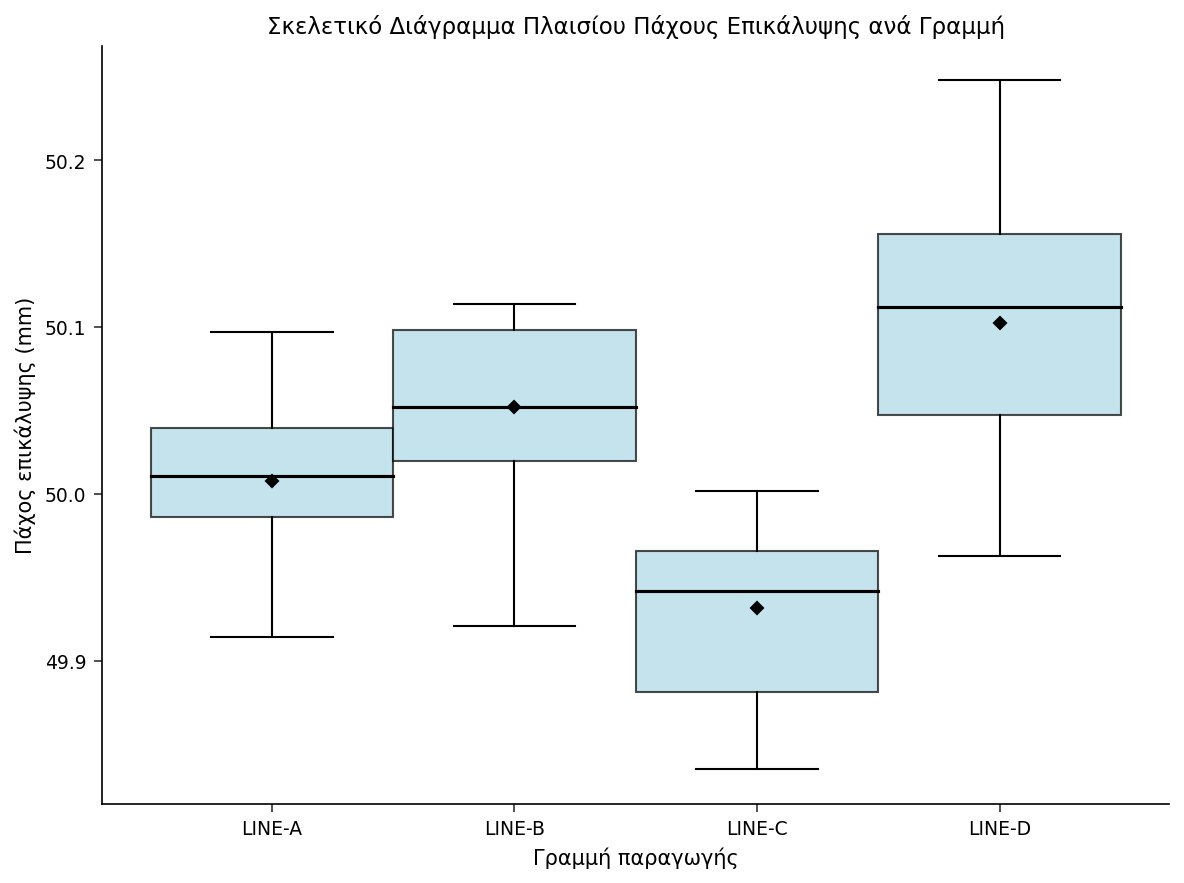

In [3]:
TITLE 'Σκελετικό Διάγραμμα Πλαισίου Πάχους Επικάλυψης ανά Γραμμή';
ΔΙΑΔΙΚΑΣΙΑ boxplot ΔΕΔΟΜΕΝΑ=ProcessMeas;
   PLOT Thickness*Line;
ΕΚΤΕΛΕΣΗ;

## Βήμα 4 — Σχηματικό διάγραμμα πλαισίου

Μεταβαίνουμε στο `BOXSTYLE=SCHEMATIC`. Στο σχηματικό στυλ κάθε μουστάκι καλύπτεται στην πιο ακραία παρατήρηση που βρίσκεται ακόμα εντός των φραχτών 1.5 × IQR, και οποιοδήποτε σημείο πέρα από έναν φράχτη σχεδιάζεται ως ξεχωριστός δείκτης ακραίας τιμής. Σε αυτό το δείγμα καμία γραμμή δεν έχει ακραία τιμή εκτός φράχτη — η διασπορά κάθε γραμμής είναι αρκετά συμπαγής ώστε τα μουστάκια να φτάνουν το πραγματικό ελάχιστο και μέγιστο — οπότε το σχηματικό διάγραμμα μοιάζει με το σκελετικό, το οποίο είναι από μόνο του ένα χρήσιμο αποτέλεσμα: λέει στον μηχανικό ότι καμία από τις τέσσερις γραμμές δεν βγάζει ακραία εξαρτήματα. Τα σώματα των πλαισίων εξακολουθούν να καθιστούν προφανείς με μια ματιά τις μετατοπίσεις από γραμμή σε γραμμή, και το Βήμα 5 τις ποσοτικοποιεί ως προς τα όρια προδιαγραφής.

                             Σχηματικό Διάγραμμα Πλαισίου SPC Πάχους Επικάλυψης ανά Γραμμή                              

    Σχηματικό Διάγραμμα Πλαισίου SPC Πάχους Επικάλυψης ανά Γραμμή

                                                 The BOXPLOT Procedure

Schematic Plots for Πάχος επικάλυψης (mm)

Γραμμή παραγωγής      N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
LINE-A               38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
LINE-B               19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
LINE-C               21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
LINE-D               22        49.96        50.05        50.11        50.16        50.25        50.10         0.08
------------


NOTE: Option TITLE changed to Σχηματικό Διάγραμμα Πλαισίου SPC Πάχους Επικάλυψης ανά Γραμμή.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: ODS plot written: boxplot.spec.json


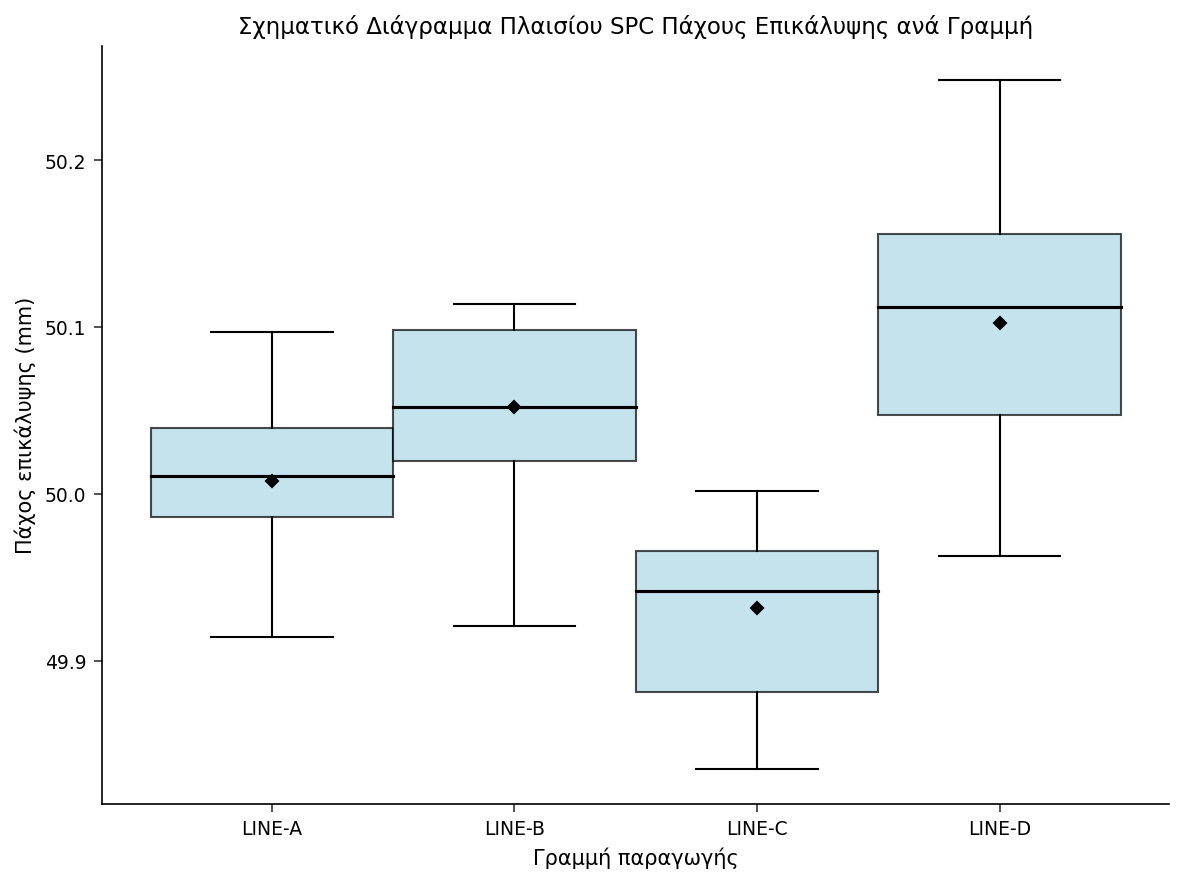

In [4]:
TITLE 'Σχηματικό Διάγραμμα Πλαισίου SPC Πάχους Επικάλυψης ανά Γραμμή';
ΔΙΑΔΙΚΑΣΙΑ boxplot ΔΕΔΟΜΕΝΑ=ProcessMeas;
   PLOT Thickness*Line / boxstyle=schematic;
ΕΚΤΕΛΕΣΗ;

## Βήμα 5 — Εξαγωγή στατιστικών πλαισίου και αξιολόγηση ως προς τα όρια προδιαγραφής

Η επιλογή `OUTBOX=` καταγράφει κάθε υπολογισμένο στατιστικό στοιχείο πλαισίου σε ένα σύνολο δεδομένων — για κάθε γραμμή: το κάτω μουστάκι (`L`), το Q1 (`1`), τη μέση τιμή (`X`), τη διάμεσο (`M`), το Q3 (`3`), το άνω μουστάκι (`H`), την τυπική απόκλιση (`S`) και το N. Αυτή είναι η αριθμητική εγγραφή που χρειάζεται ένας ελεγκτής πίσω από την εικόνα, και είναι επίσης ο πιο καθαρός τρόπος για να ελεγχθεί κάθε γραμμή ως προς την προδιαγραφή 49.80 / 50.20 mm. Ενεργοποιούμε το `GRID` για ευκολότερη ανάγνωση, εξάγουμε το `BoxStats`, το εκτυπώνουμε, και έπειτα εκτελούμε ένα σύντομο βήμα DATA που επισημαίνει κάθε γραμμή της οποίας το εύρος μουστακιού ξεπερνά ένα όριο προδιαγραφής.

                             Σχηματικό Διάγραμμα Πλαισίου με Πλέγμα και Εξαγωγή Στατιστικών                             

 Σχηματικό Διάγραμμα Πλαισίου με Πλέγμα και Εξαγωγή Στατιστικών

                                                 The BOXPLOT Procedure

Schematic Plots for Πάχος επικάλυψης (mm)

Γραμμή παραγωγής      N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
LINE-A               38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
LINE-B               19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
LINE-C               21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
LINE-D               22        49.96        50.05        50.11        50.16        50.25        50.10         0.08
--------------


NOTE: Option TITLE changed to Σχηματικό Διάγραμμα Πλαισίου με Πλέγμα και Εξαγωγή Στατιστικών.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: Output dataset BOXSTATS created with 4 observations.
NOTE: ODS plot written: boxplot.spec.json
NOTE: Option TITLE changed to Υπολογισμένα Στατιστικά Πλαισίου (OUTBOX=).
NOTE: PROC PRINT data=BoxStats

NOTE: PROC PRINT completed: 4 observations printed, 9 variables
NOTE: DATA SpecCheck


NOTE: Read 4 rows from BoxStats.
NOTE: Wrote SpecCheck (4 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Αξιολόγηση Ορίων Προδιαγραφής ανά Γραμμή.
NOTE: PROC PRINT data=SpecCheck

NOTE: PROC PRINT completed: 4 observations printed, 6 variables


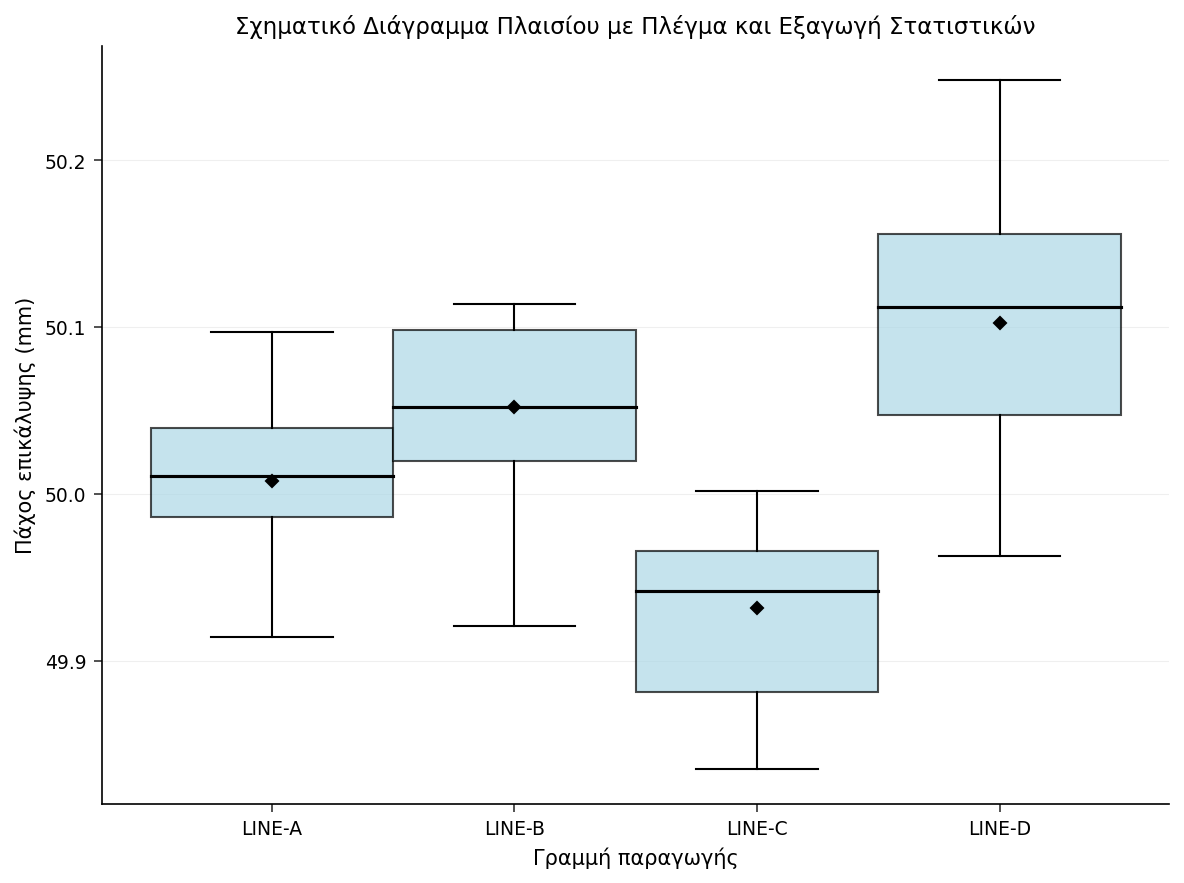

In [5]:
TITLE 'Σχηματικό Διάγραμμα Πλαισίου με Πλέγμα και Εξαγωγή Στατιστικών';
ΔΙΑΔΙΚΑΣΙΑ boxplot ΔΕΔΟΜΕΝΑ=ProcessMeas;
   PLOT Thickness*Line / boxstyle=schematic
                         grid
                         outbox=BoxStats;
ΕΚΤΕΛΕΣΗ;

TITLE 'Υπολογισμένα Στατιστικά Πλαισίου (OUTBOX=)';
ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=BoxStats noobs label;
   ΕΤΙΚΕΤΑ Line='Γραμμή';
ΕΚΤΕΛΕΣΗ;

/* Assess each line against the 49.80 / 50.20 mm specification    */
/* using the exported whisker endpoints (THICKNESSL = low whisker, */
/* THICKNESSH = high whisker).                                     */
ΔΕΔΟΜΕΝΑ SpecCheck;
   ΟΡΙΣΜΟΣ BoxStats;
   LENGTH Status $80;
   LSL = 49.80;
   USL = 50.20;
   ΕΑΝ THICKNESSH > USL ΤΟΤΕ Status = 'Άνω τιμές υπερβαίνουν το USL';
   ΑΛΛΙΩΣ ΕΑΝ THICKNESSL < LSL ΤΟΤΕ Status = 'Κάτω τιμές κάτω από το LSL';
   ΑΛΛΙΩΣ Status = 'Εντός προδιαγραφής';
   ΚΡΑΤΗΣΗ LINE THICKNESSL THICKNESSH LSL USL Status;
ΕΚΤΕΛΕΣΗ;

TITLE 'Αξιολόγηση Ορίων Προδιαγραφής ανά Γραμμή';
ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=SpecCheck noobs label;
   ΕΤΙΚΕΤΑ Line='Γραμμή' THICKNESSL='Κάτω μουστάκι' THICKNESSH='Άνω μουστάκι' LSL='Κάτω όριο' USL='Άνω όριο' Status='Κατάσταση';
ΕΚΤΕΛΕΣΗ;

## Βήμα 6 — Διατήρηση ιστορικού παρακολούθησης και επανασχεδιασμός από αυτό

Στον συνεχή SPC σπάνια επανασαρώνετε κάθε ακατέργαστη μέτρηση. Το `OUTHISTORY=` γράφει μία γραμμή περίληψης ανά γραμμή παραγωγής (την ίδια διάταξη που καταναλώνει το `HISTORY=`), ώστε τα βαριά ακατέργαστα δεδομένα να μπορούν να αρχειοθετηθούν. Παρακάτω εξάγουμε το `LineHistory`, το εκτυπώνουμε, και έπειτα αποδεικνύουμε τη διαδρομή μετ' επιστροφής τροφοδοτώντας το κατευθείαν πίσω σε ένα νέο `PROC BOXPLOT` μέσω του `HISTORY=` — ακριβώς όπως ένας καθημερινός πίνακας ελέγχου θα επαναχρησιμοποιούσε προ-συγκεντρωμένα στατιστικά υποομάδων.

                                              Εξαγωγή Ιστορικού Υποομάδων                                               

                                  Εξαγωγή Ιστορικού Υποομάδων

                                                 The BOXPLOT Procedure

Skeletal Plots for Πάχος επικάλυψης (mm)

Γραμμή παραγωγής      N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
LINE-A               38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
LINE-B               19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
LINE-C               21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
LINE-D               22        49.96        50.05        50.11        50.16        50.25        50.10         0.08
-----------------


NOTE: Option TITLE changed to Εξαγωγή Ιστορικού Υποομάδων.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: Output dataset LINEHISTORY created with 4 observations.
NOTE: ODS plot written: boxplot.spec.json
NOTE: Option TITLE changed to Σύνολο Δεδομένων Ιστορικού Περίληψης (μία γραμμή ανά γραμμή παραγωγής).
NOTE: PROC PRINT data=LineHistory

NOTE: PROC PRINT completed: 4 observations printed, 9 variables
NOTE: Option TITLE changed to Διάγραμμα Πλαισίου Ανακατασκευασμένο από το Ιστορικό Περίληψης.
NOTE: PROC BOXPLOT history=LineHistory

NOTE: ODS plot written: boxplot.spec.json


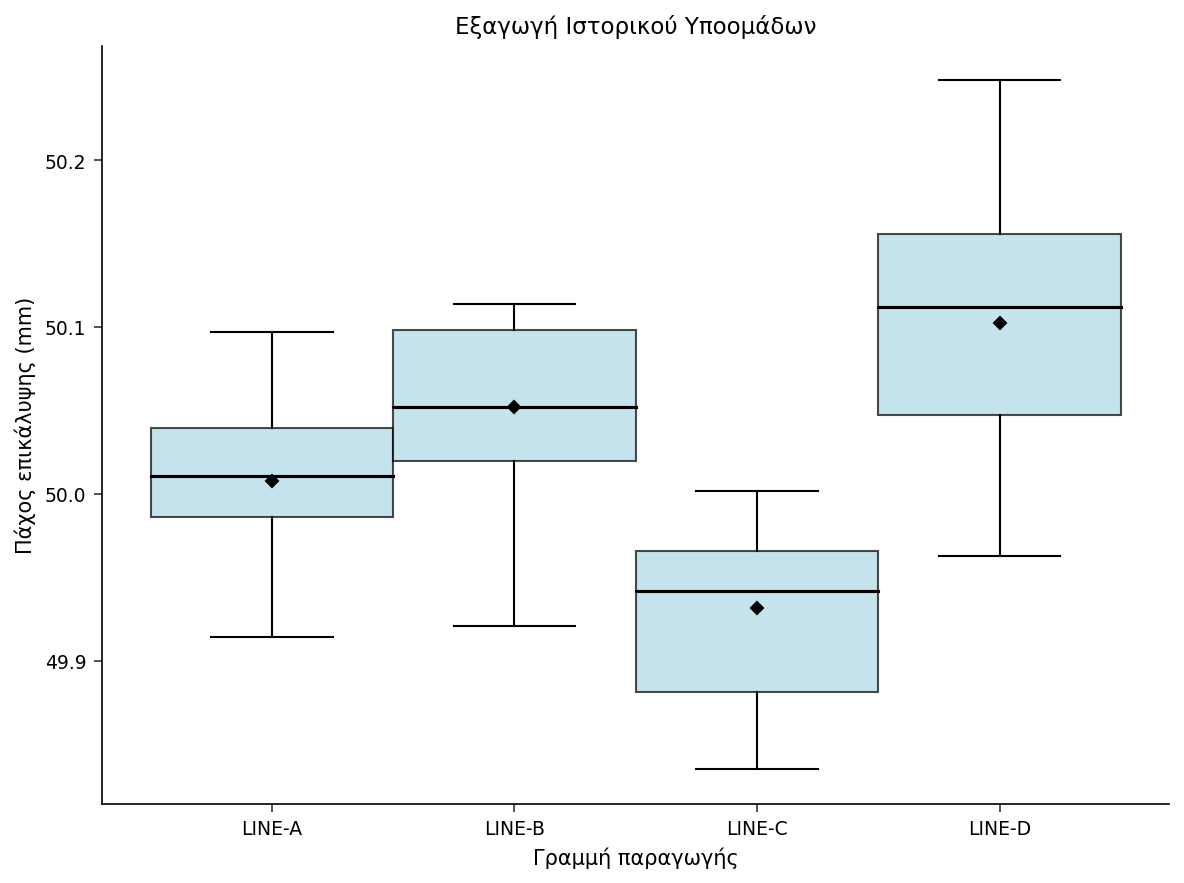

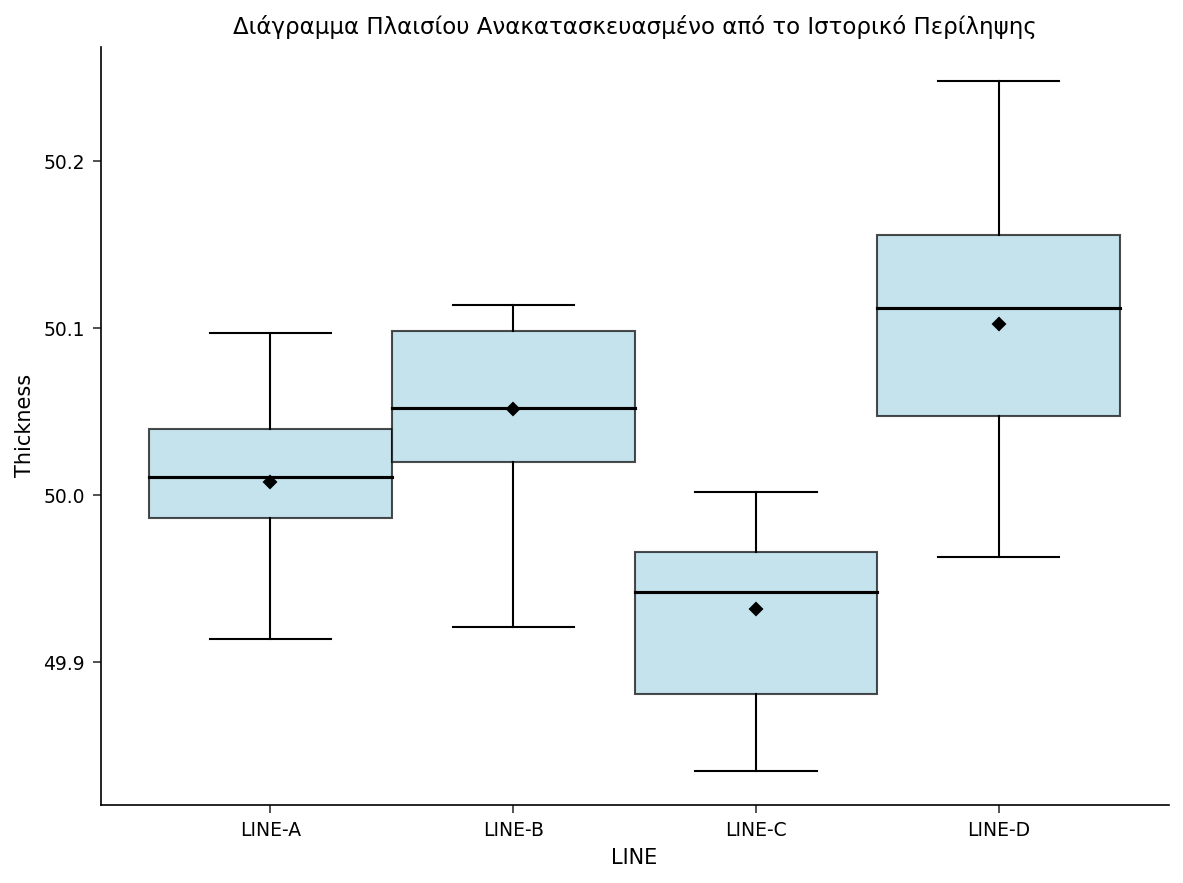

In [6]:
TITLE 'Εξαγωγή Ιστορικού Υποομάδων';
ΔΙΑΔΙΚΑΣΙΑ boxplot ΔΕΔΟΜΕΝΑ=ProcessMeas;
   PLOT Thickness*Line / outhistory=LineHistory;
ΕΚΤΕΛΕΣΗ;

TITLE 'Σύνολο Δεδομένων Ιστορικού Περίληψης (μία γραμμή ανά γραμμή παραγωγής)';
ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=LineHistory noobs label;
   ΕΤΙΚΕΤΑ Line='Γραμμή';
ΕΚΤΕΛΕΣΗ;

TITLE 'Διάγραμμα Πλαισίου Ανακατασκευασμένο από το Ιστορικό Περίληψης';
ΔΙΑΔΙΚΑΣΙΑ boxplot history=LineHistory;
   PLOT Thickness*Line;
ΕΚΤΕΛΕΣΗ;

## Ερμηνεία των αποτελεσμάτων

Διαβάζοντας τα διαγράμματα πλαισίου μαζί με το προφίλ του `PROC MEANS`, τον πίνακα `OUTBOX=` και την αξιολόγηση ορίων προδιαγραφής:

- **Κεντράρισμα.** Η `LINE-A` είναι η καλύτερα κεντραρισμένη στον στόχο των 50.00 mm (μέση τιμή 50.008 mm, διάμεσος 50.011 mm). Η `LINE-B` τρέχει ελαφρώς ψηλά (μέση τιμή 50.052 mm). Η `LINE-C` τρέχει χαμηλά (μέση τιμή 49.932 mm, διάμεσος 49.942 mm), η γραμμή που μετατοπίζεται προς το LSL. Η `LINE-D` τρέχει ψηλά (μέση τιμή 50.102 mm, διάμεσος 50.112 mm), η γραμμή πλησιέστερα στο USL.
- **Διασπορά.** Η `LINE-D` εμφανίζει το ευρύτερο πλαίσιο και τα μακρύτερα μουστάκια — η τυπική της απόκλιση 0.080 mm είναι περίπου 60–80% μεγαλύτερη από τις άλλες τρεις γραμμές (0.045–0.051 mm), επισημαίνοντάς την ως τη λιγότερο σταθερή γραμμή και τον καλύτερο υποψήφιο για μελέτη μείωσης της μεταβλητότητας. Η `LINE-A` είναι η πιο συμπαγής (τυπική απόκλιση 0.045 mm).
- **Ουρές.** Στο σχηματικό στυλ καμία γραμμή δεν παράγει ακραία τιμή εκτός φράχτη: κάθε μουστάκι φτάνει το πραγματικό ελάχιστο/μέγιστο της γραμμής του, οπότε η διεργασία δεν βγάζει μεμονωμένα ακραία εξαρτήματα. Οι διαφορές διασποράς οφείλονται στον κύριο όγκο κάθε κατανομής, όχι σε αδέσποτα σημεία.
- **Συμμόρφωση με προδιαγραφές.** Τα άκρα μουστακιών του `OUTBOX=`, αξιολογημένα ως προς τα 49.80 / 50.20 mm, τοποθετούν τις `LINE-A`, `LINE-B` και `LINE-C` πλήρως **εντός προδιαγραφών**. Η `LINE-D` αποτελεί την εξαίρεση: το άνω μουστάκι της φτάνει τα **50.248 mm**, πέρα από το **USL των 50.20 mm** — τα υψηλά εξαρτήματα στη `LINE-D` υπερβαίνουν την άνω προδιαγραφή.
- **Λειτουργικοποίηση.** Το σύνολο δεδομένων `OUTBOX=` δίνει στους ελεγκτές τα ακριβή τεταρτημόρια, τα άκρα των μουστακιών, τη μέση τιμή και την τυπική απόκλιση πίσω από την εικόνα, και το `OUTHISTORY=` παρέχει μια συμπαγή, επανασχεδιάσιμη περίληψη μιας γραμμής ανά γραμμή παραγωγής (Βήμα 6) ώστε το διάγραμμα να μπορεί να αναπαραχθεί σε προγραμματισμένη βάση χωρίς διατήρηση των ακατέργαστων μετρήσεων — το διάγραμμα πλαισίου που ανακατασκευάζεται από την περίληψη είναι πανομοιότυπο με εκείνο που σχεδιάστηκε από τα ακατέργαστα δεδομένα.

**Ενέργειες προς υλοποίηση:** δώστε προτεραιότητα στη `LINE-D` — τόσο επανακεντράρετέ την προς τα κάτω προς τον στόχο όσο και ξεκινήστε μια μελέτη μείωσης της μεταβλητότητας για να τραβήξετε το άνω μουστάκι της πίσω εντός του USL· σπρώξτε τη `LINE-C` προς τα πάνω προς τον στόχο πριν η κάτω ουρά της φτάσει το LSL· οι `LINE-A` και `LINE-B` λειτουργούν αποδεκτά.